Pavankumar Shinde

CO22BTECH11008

Computational Physics, Assignment 2

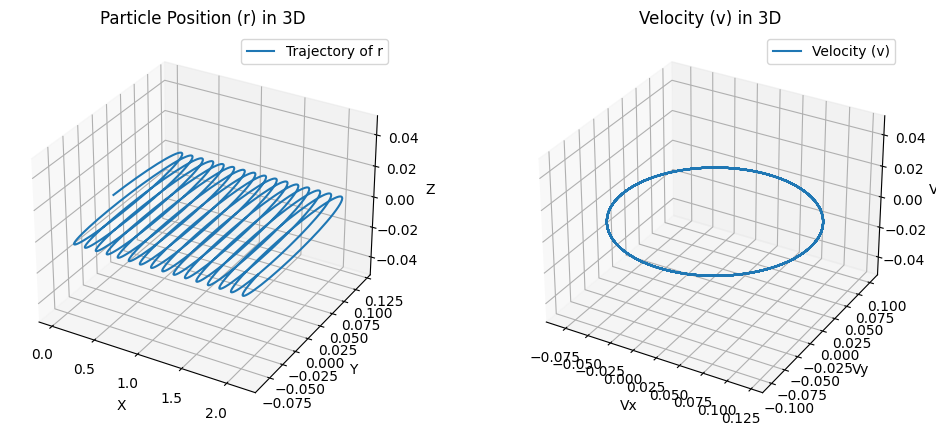

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#Constants
q = 1
m = 1
t = 0

#Initial conditions
r = np.array([0.0, 0.0, 0.0])
v = np.array([0.0, 0.1, 0.0])
E = np.array([0.0, 0.02, 0.0])
B=np.array([0.0,0.0,(1+0.1*r[0] +0.01*t)])

#Time
N = 1000
t0 = 0
tf = 100
delta_t = (tf - t0) / N

#storing locations and velocity
r_vals = []
v_vals = []

def G2(t,r,v):
    return v

def G1(t,r,v):
    return (q/m )*(E +np.cross(v , B))


#RK4
for i in range(N):
    k11=delta_t *G1(t,r,v)
    k12=delta_t * G1(t+delta_t/2,r,v+k11/2)
    k13=delta_t* G1(t+ delta_t/2,r,v +k12/2)
    k14=delta_t * G1(t +delta_t,r,v+k13)
    
    v= v+(k11/2 +k12 +k13 +k14/2)/3
    # ------------------
    
    k21=delta_t*G2(t,r,v)
    k22=delta_t*G2(t+delta_t/2,r+k21/2,v)
    k23=delta_t*G2(t+delta_t/2,r+k22/2,v)
    k24=delta_t*G2(t+delta_t,r+k23,v)
    
    r=r +(k21/2 +k22 +k23 +k24/2)/3
    # -----------------------
    
    r_vals.append(r.copy())
    v_vals.append(v.copy())
    
    t += delta_t 
    
    
r_vals = np.array(r_vals)
v_vals = np.array(v_vals)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection="3d")
ax1.plot(r_vals[:, 0], r_vals[:, 1], r_vals[:, 2], label="Trajectory of r")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")
ax1.set_title("Particle Position (r) in 3D")
ax1.legend()

# 3D Plot for v
ax2 = fig.add_subplot(122, projection="3d")
ax2.plot(v_vals[:, 0], v_vals[:, 1], v_vals[:, 2], label="Velocity (v)")
ax2.set_xlabel("Vx")
ax2.set_ylabel("Vy")
ax2.set_zlabel("Vz")
ax2.set_title("Velocity (v) in 3D")
ax2.legend()
